In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib
import varray as va
import matplotlib.patches as mpatches
import ldax_analysis as lan
from matplotlib.patches import Ellipse
from scipy.optimize import curve_fit
import tqdm
import matplotlib.dates as mdates
import processingFunctions
from datetime import datetime
plt.style.use('../style.mplstyle')
rq_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004dope/'

#Enter what data sets you want to analyze followed by number of files to process
dates = [
    '2026-07-15-1418,50',
    '2026-07-16-1352,50',
    '2026-07-17-0901,50',
    '2026-07-17-1515,50',
    '2026-07-20-0836,50',
    '2026-07-20-1218,50',
    '2026-07-20-1633,50',
    # '2026-07-21-0919,50',
    # '2026-07-21-1258,50',
    # '2026-07-21-1616,3',
    # '2026-07-22-1036,39',
    # '2026-07-22-1311,50',
    # '2026-07-22-1626,50',
    # '2026-07-23-0847,50',
    # '2026-07-23-1315,50',
    # '2026-07-23-1622,50',
    # '2026-07-24-0902,50',
    # '2026-07-24-1718,50',
    # '2026-07-27-0715,50',
    # '2026-07-27-1023,50',
    # '2026-07-27-1337,50',
    # '2026-07-27-1644,50',
    # '2026-07-28-0917,50',
    # '2026-07-28-1239,50',
    # '2026-07-28-1636,50',
    # '2026-07-29-0839,50',
    # '2026-07-29-1440,50',
    # '2026-07-31-0910,50',
    # '2026-07-31-1553,50',
         ]
dataset_labels = [
    '2026-07-15 14:18',
    '2026-07-16 13:52',
    '2026-07-17 09:01',
    '2026-07-17 15:15',
    '2026-07-20 08:36',
    '2026-07-20 12:18',
    '2026-07-20 16:33',
    '2026-07-21 09:19',
    '2026-07-21 12:58',
    '2026-07-21 16:16',
    '2026-07-22 10:36',
    '2026-07-22 13:11',
    '2026-07-22 16:26',
    '2026-07-23 08:47',
    '2026-07-23 13:15',
    '2026-07-23 16:22',
    '2026-07-24 09:02',
    '2026-07-24 17:18',
    '2026-07-27 07:15',
    '2026-07-27 10:23',
    '2026-07-27 13:37',
    '2026-07-27 16:44',
    '2026-07-28 09:17',
    '2026-07-28 12:39',
    '2026-07-28 16:36',
    '2026-07-29 08:39',
    '2026-07-29 14:40',
    '2026-07-31 09:10',
    '2026-07-31 15:53',
]

rq_names = [
    'p_phe',
    'p_aft',
    'p_bnds',
    'e_timestamps',
    'ss_s1_phe_ch',
    'ss_s1_phe',
    'ss_s1_aft',
    'ss_s1_mhf',
    'ss_s2_phe_ch',
    'ss_s2_phe',
    'ss_s2_aft',
    'ss_s2_x_raw',
    'ss_s2_y_raw',
    'ss_s2_r_raw',
    'ss_s2_drift_time',
    'ss_bad_phe',
    'ss_e_timestamps'
]

In [2]:
#Collect all data from selected files and store them in dict
d = processingFunctions.get_all_data(dates, dataset_labels, rq_path, rq_names)

Finished collecting data for 2026-07-15 14:18
Finished collecting data for 2026-07-16 13:52
Finished collecting data for 2026-07-17 09:01
Finished collecting data for 2026-07-17 15:15
Finished collecting data for 2026-07-20 08:36
Finished collecting data for 2026-07-20 12:18
Finished collecting data for 2026-07-20 16:33


In [3]:
def plot2d(
    x,
    y,
    x_range=None,
    y_range=None,
    x_bins=50,
    y_bins=50,
    flag_log=False,
    flag_mask=True,
    y_log_scale=False,
    cmap=None,
):
    if cmap is None:
        cmap = matplotlib.cm.viridis

    if x_range is None:
        x_range = [x.min(), x.max()]
    if y_range is None:
        y_range = [y.min(), y.max()]

    if x_range[1] < x_range[0]:
        x_range = x_range[::-1]
    if y_range[1] < y_range[0]:
        y_range = y_range[::-1]

    # x bin edges (always linear)
    x_xe = np.linspace(x_range[0], x_range[1], x_bins + 1)

    # y bin edges
    if y_log_scale:
        if y_range[0] <= 0:
            raise ValueError("y_range must be positive for logarithmic y scale.")
        x_ye = np.logspace(
            np.log10(y_range[0]),
            np.log10(y_range[1]),
            y_bins + 1,
        )
    else:
        x_ye = np.linspace(y_range[0], y_range[1], y_bins + 1)

    # Histogram
    n = np.histogramdd(np.column_stack((x, y)), bins=[x_xe, x_ye])[0]

    if flag_mask:
        n_max = n[n > 0].max()
        n_min = n[n > 0].min()
        n = np.ma.masked_where(n <= 0, n)
    else:
        if flag_log:
            n[n <= 0] = 0.1
        n_max = n.max()
        n_min = n.min()

    # Color normalization
    if flag_log:
        n_Norm = matplotlib.colors.LogNorm(vmin=n_min, vmax=n_max)
    else:
        n_Norm = matplotlib.colors.Normalize(vmin=n_min, vmax=n_max)

    h = plt.pcolormesh(
        x_xe,
        x_ye,
        n.T,
        norm=n_Norm,
        cmap=cmap,
        shading="auto",
    )

    h.set_edgecolor("face")
    h.set_linewidth(0.001)

    if y_log_scale:
        plt.yscale("log")

    if flag_log and not flag_mask:
        cMax = h.get_clim()[1]
        h.set_clim((0.8, cMax))

    return n

In [3]:
electron_lifetimes = [
    50,    # '2026-07-15 14:18',
    3.10,    # '2026-07-16 13:52',
    2,    # '2026-07-17 09:01',
    2,    # '2026-07-17 15:15',
    1,    # '2026-07-20 08:36',
    1,    # '2026-07-20 12:18',
    0.9,    # '2026-07-20 16:33',
    0.9,    # '2026-07-21 09:19',
    1.00,    # '2026-07-21 12:58',
    1.10,    # '2026-07-21 16:16',
    1.60,    # '2026-07-22 10:36',
    1.70,    # '2026-07-22 13:11',
    1.85,    # '2026-07-22 16:26',
    2.60,    # '2026-07-23 08:47',
    3.00,    # '2026-07-23 13:15',
    3.20,    # '2026-07-23 16:22',
    4.90,    # '2026-07-24 09:02',
    6.00,    # '2026-07-24 17:18',
    12.60,    # '2026-07-27 07:15',
    12.80,    # '2026-07-27 10:23',
    13.20,    # '2026-07-27 13:37',
    14.00,    # '2026-07-27 16:44',
    13.20,    # '2026-07-28 09:17',
    13.30,    # '2026-07-28 12:39',
    13.50,    # '2026-07-28 16:36',
    13.50,    # '2026-07-29 08:39',
    13.30,    # '2026-07-29 14:40',
    13.50,    # '2026-07-31 09:10',
    13.50,    # '2026-07-31 15:53',
]

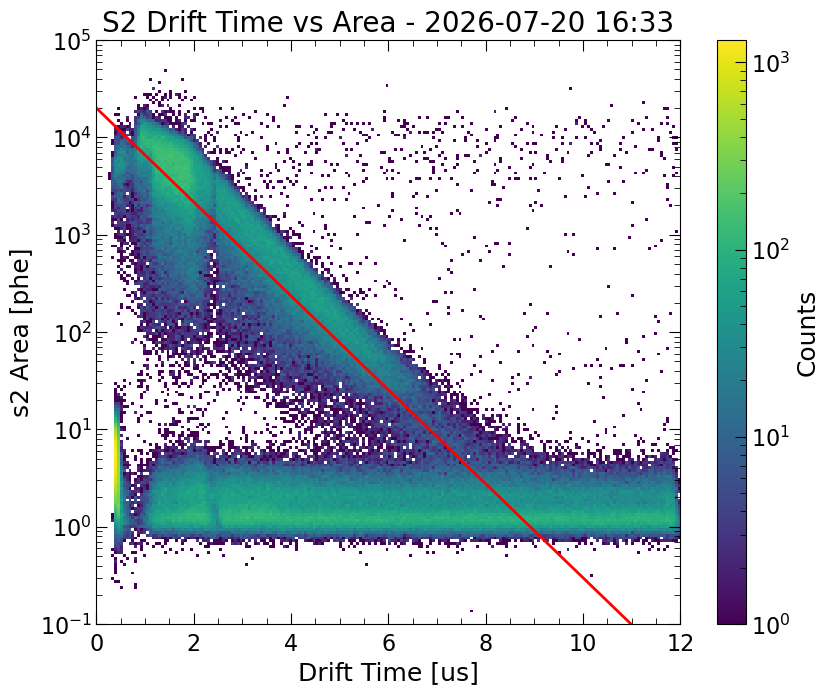

In [ ]:

#for label in dataset_labels:
i = 6
label=dataset_labels[i]
dataset = d[label]
plt.figure(figsize=(10,8))
plot2d(dataset['ss_s2_drift_time']/100, dataset['ss_s2_phe'], (0,12), (0.1, 1e5), x_bins=200, y_bins=200, flag_log=True, y_log_scale=True)
x = np.linspace(0, 12, 100)
y = 2*10**4*np.exp(-x/electron_lifetimes[dataset_labels.index(label)])
plt.plot(x, y, color='red')
#plt.yscale('log')
plt.xlim(0, 12)
#plt.axhline(y=1e3, color='red')
plt.xlabel("Drift Time [us]")
plt.ylabel("s2 Area [phe]")
plt.title("S2 Drift Time vs Area - " + label)
plt.colorbar(label="Counts")
plt.show()

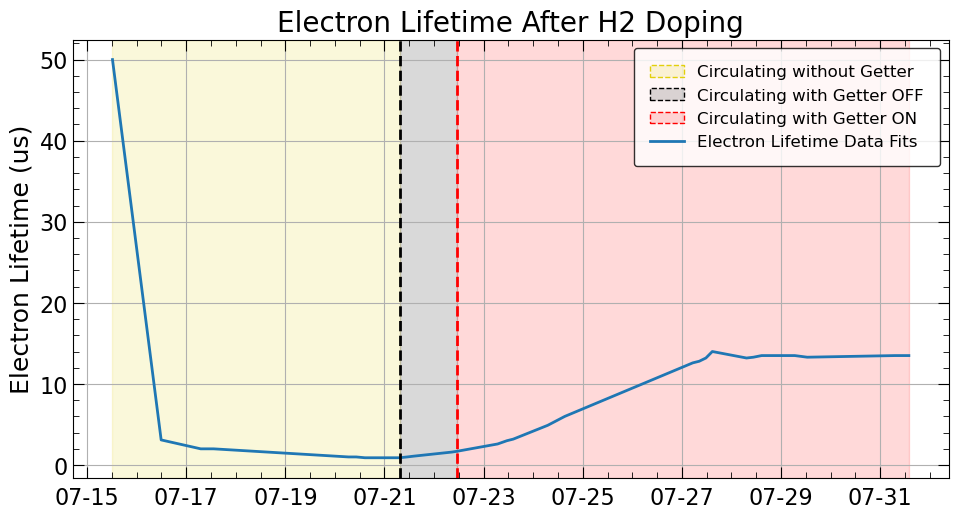

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
plt.rcParams.update({
    'axes.labelsize': 16,      # Axis labels (x and y)
    'xtick.labelsize': 16,     # X-axis tick labels
    'ytick.labelsize': 16,     # Y-axis tick labels
    'font.size': 12            # Default fallback text size
})
dates = [datetime.strptime(s, "%Y-%m-%d %H:%M") for s in dataset_labels]

ax.plot(dates, electron_lifetimes, label="Electron Lifetime Data")
plt.axvspan(dates[0], dates[7], color='#E2D00B', alpha=0.15)
plt.axvline(x=dates[7], linestyle="--", color='black', label="Started Circulating Through Getter")
plt.axvspan(dates[7], dates[11], color='black', alpha=0.15)
plt.axvline(x=dates[11], linestyle="--", color='red', label="Getter Turned ON")
plt.axvspan(dates[11], dates[len(dates)-1], color='red', alpha=0.15)

# Format: YYYY-MM-DD HH:MM
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d")
)

# Tick every day
ax.xaxis.set_major_locator(mdates.HourLocator(interval=48))
legend_elements = [
    mpatches.Patch(label='Circulating without Getter', facecolor=(0.886, 0.816, 0.043, 0.15) , edgecolor=(0.886, 0.816, 0.043, 1.0), linestyle="--", linewidth=1),
    mpatches.Patch(label='Circulating with Getter OFF', facecolor=(0.0, 0.0, 0.0, 0.15), edgecolor="black", linestyle="--", linewidth=1),
    mpatches.Patch(label='Circulating with Getter ON', facecolor=(1, 0, 0, 0.15) , edgecolor="red", linestyle="--" , linewidth=1),
    matplotlib.lines.Line2D([0], [0], color='#1f77b4', lw=2, linestyle='-', label="Electron Lifetime Data Fits")


]
plt.legend(handles=legend_elements, loc='upper right', frameon=True, edgecolor="black", borderpad=1)


# Explicitly assign positions and their respective text strings
#ax.set_xticks(electron_lifetimes, labels=dataset_labels)
plt.grid(True)
plt.title("Electron Lifetime After H2 Doping")
plt.ylabel("Electron Lifetime (us)")
plt.show()